# Lifestyle-Based Depression Risk Classification

> Given demographic, physical-health, diet, physical-activity, sleep, screen-use, and social variables available when a student submits a survey, classify that student as **higher risk** or **lower risk** for depression at the time of submission. This is ultimately to support institutional screening and intervention planning.

The binary target is derived from `Psy_Depression`:

- `1` — higher risk: `Psy_Depression >= 10`
- `0` — lower risk: `Psy_Depression < 10`

## Important methodological boundary

The target is a **screening proxy**, not a clinical diagnosis. The learned models deliberately exclude:

- `Psy_Depression` itself,
- all individual `Psy_PHQ*` questions,
- `Psy_Anxiety`,
- all individual `Psy_GAD*` questions,
- all stress variables (`Psy_Stress*`),
- identifier and location fields that are unlikely to generalize.

The primary metric is **recall for the higher-risk class**. Precision, F1, PR-AUC, ROC-AUC, specificity, and confusion matrices are also reported so that high recall is not achieved by flagging nearly everyone.


`Psy_Stress` is retained separately only to construct the Section 6 stress-based comparison rule. It is never supplied to the learned models.

In [1]:
%pip install -q pandas numpy matplotlib scikit-learn imbalanced-learn joblib

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

try:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("imbalanced-learn available:", IMBLEARN_AVAILABLE)


imbalanced-learn available: True


## 1. Load the attached dataset

The cell searches common notebook locations for the original Chinese filename and for any CSV containing the expected `Psy_Depression` column. In Google Colab, it will offer a file-upload prompt if the dataset is not already present.


In [2]:
EXPECTED_FILENAME = "中国大学生生活方式及其身心健康样例数据集.csv"

def locate_dataset(expected_filename: str = EXPECTED_FILENAME) -> Path:
    search_roots = [
        Path.cwd(),
        Path("/content"),
        Path("/mnt/data"),
    ]

    exact_candidates = [root / expected_filename for root in search_roots]
    for candidate in exact_candidates:
        if candidate.exists():
            return candidate

    # Fall back to inspecting CSV headers.
    for root in search_roots:
        if not root.exists():
            continue
        for candidate in root.glob("*.csv"):
            try:
                header = pd.read_csv(candidate, nrows=0, encoding="utf-8-sig")
                if "Psy_Depression" in header.columns:
                    return candidate
            except Exception:
                continue

    # Colab upload fallback.
    try:
        from google.colab import files
        print("Dataset not found locally. Please upload the attached CSV.")
        uploaded = files.upload()
        if uploaded:
            uploaded_path = Path(next(iter(uploaded)))
            return uploaded_path
    except ImportError:
        pass

    raise FileNotFoundError(
        f"Could not find {expected_filename!r}. Place the CSV beside this notebook "
        "or update EXPECTED_FILENAME."
    )

DATA_PATH = locate_dataset()
print("Using dataset:", DATA_PATH)

df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print("Raw shape:", df_raw.shape)
display(df_raw.head())


Dataset not found locally. Please upload the attached CSV.


Saving 中国大学生生活方式及其身心健康样例数据集.csv to 中国大学生生活方式及其身心健康样例数据集.csv
Using dataset: 中国大学生生活方式及其身心健康样例数据集.csv
Raw shape: (2717, 82)


,Demo_Grade,Demo_Major,Demo_Gender,Demo_Age,PhyH_Height_cm,PhyH_Weight_kg,PhyH_BMI,Demo_Hukou,Demo_FatherEducation,Demo_MotherEducation,...,Psy_PHQ5,Psy_PHQ6,Psy_PHQ7,Psy_PHQ8,Psy_PHQ9,Screen_PhoneAddiction,Social_Relative,Social_Offline,Social_Online,Social_Total
0,1,1,1,17,175.0,63.0,20.571429,2,4,4,...,2,2,3,1,1,49,3,7,12,22
1,1,1,1,19,178.0,65.0,20.515086,2,1,1,...,2,1,3,1,1,28,10,10,0,20
2,1,1,1,18,175.0,75.0,24.489796,2,3,3,...,1,1,1,1,1,8,9,0,3,12
3,1,1,1,18,182.0,85.0,25.661152,2,2,2,...,1,1,1,1,1,29,8,12,3,23
4,1,1,1,18,162.0,52.0,19.814053,1,3,2,...,2,1,2,1,1,33,3,5,6,14


## 2. Audit the data and construct the target

In [4]:
TARGET_SOURCE = "Psy_Depression"
TARGET = "high_depression_risk"

if TARGET_SOURCE not in df_raw.columns:
    raise KeyError(f"Required target source column {TARGET_SOURCE!r} is missing.")

df = df_raw.copy()
df.columns = df.columns.astype(str).str.strip()

# Convert the PHQ/depression total to numeric before defining the label.
df[TARGET_SOURCE] = pd.to_numeric(df[TARGET_SOURCE], errors="coerce")
missing_target = int(df[TARGET_SOURCE].isna().sum())
if missing_target:
    print(f"Dropping {missing_target} rows with missing/unparseable target values.")
    df = df.dropna(subset=[TARGET_SOURCE]).copy()

df[TARGET] = (df[TARGET_SOURCE] >= 10).astype(int)

target_summary = pd.DataFrame({
    "count": df[TARGET].value_counts().sort_index(),
    "proportion": df[TARGET].value_counts(normalize=True).sort_index(),
})
target_summary.index = ["lower risk (0)", "higher risk (1)"]
display(target_summary)

print("Prepared shape:", df.shape)
print("Duplicate full rows:", int(df.duplicated().sum()))
print("Total missing cells:", int(df.isna().sum().sum()))


,count,proportion
lower risk (0),2529,0.930806
higher risk (1),188,0.069194


Prepared shape: (2717, 83)
Duplicate full rows: 0
Total missing cells: 490


In [5]:
# Compact missingness and data-type audit
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": 100 * df.isna().mean(),
    "unique_n": df.nunique(dropna=True),
}).sort_values(["missing_pct", "unique_n"], ascending=[False, True])

display(audit.head(25))


,dtype,missing_n,missing_pct,unique_n
Lifestyle_AlcoholHabit,float64,490,18.034597,5
Demo_Gender,int64,0,0.000000,2
Demo_Hukou,int64,0,0.000000,2
Demo_SiblingsCount,int64,0,0.000000,2
Sleep_SleepaidMedications_StimulatingBeverages,int64,0,0.000000,2
high_depression_risk,int64,0,0.000000,2
Demo_Major,int64,0,0.000000,3
PhyH_HealthStatus,int64,0,0.000000,3
PA_IPAQ_CategoryRecoded,int64,0,0.000000,3
Demo_FatherEducation,int64,0,0.000000,4


## 3. Remove leakage-prone and non-generalizable variables from the learned models

The following leakage and generalizability risks are handled here:

1. **Direct PHQ leakage:** the target total and all individual PHQ questions are removed.
2. **Near-target mental-health leakage:** total anxiety and GAD question scores are removed.
3. **Stress variables:** `Psy_Stress` and all individual `Psy_Stress*` questions are excluded from every learned model.

`Psy_Stress` remains available only in the original data frame so that Section 6 can evaluate a simple stress-based baseline. It is not included in `X`, preprocessing, model fitting, tuning, final evaluation, or inference.

`index` is treated as an identifier. Province/city and Hukou are excluded because they may encode site-specific socioeconomic patterns that do not transfer well to future institutions and could amplify geographic bias.


In [6]:
DIRECT_EXCLUSIONS = {
    "index",
    TARGET,
    TARGET_SOURCE,
    "Demo_ProvinceCity",
    "Demo_Hukou",
}

PREFIX_EXCLUSIONS = (
    "Psy_PHQ",      # individual PHQ questions
    "Psy_GAD",      # individual GAD questions
    "Psy_Stress",   # total stress score and individual stress questions
)

NEAR_TARGET_EXCLUSIONS = {
    "Psy_Anxiety",
}

excluded_columns = sorted(
    {
        col for col in df.columns
        if col in DIRECT_EXCLUSIONS
        or col in NEAR_TARGET_EXCLUSIONS
        or col.startswith(PREFIX_EXCLUSIONS)
    }
)

feature_columns = [col for col in df.columns if col not in excluded_columns]
X = df[feature_columns].copy()
y = df[TARGET].copy()

print(f"Features retained: {X.shape[1]}")
print(f"Columns excluded: {len(excluded_columns)}")
print(excluded_columns)

assert TARGET_SOURCE not in X.columns
assert not any(col.startswith("Psy_PHQ") for col in X.columns)
assert "Psy_Anxiety" not in X.columns
assert not any(col.startswith("Psy_GAD") for col in X.columns)
assert not any(col.startswith("Psy_Stress") for col in X.columns)


Features retained: 62
Columns excluded: 21
['Demo_Hukou', 'Demo_ProvinceCity', 'Psy_Anxiety', 'Psy_Depression', 'Psy_GAD1', 'Psy_GAD2', 'Psy_GAD3', 'Psy_GAD4', 'Psy_GAD5', 'Psy_GAD6', 'Psy_GAD7', 'Psy_PHQ1', 'Psy_PHQ2', 'Psy_PHQ3', 'Psy_PHQ4', 'Psy_PHQ5', 'Psy_PHQ6', 'Psy_PHQ7', 'Psy_PHQ8', 'Psy_PHQ9', 'high_depression_risk']


## 4. Stratified 70/15/15 train/validation/test split

The final test set is held untouched until the model family, hyperparameters, and probability threshold have been selected using only the training and validation sets.


In [7]:
# First hold out 30%; then divide it evenly into validation and test sets.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "rows": [len(y_train), len(y_valid), len(y_test)],
    "higher_risk_n": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "higher_risk_pct": [
        100 * y_train.mean(),
        100 * y_valid.mean(),
        100 * y_test.mean(),
    ],
}, index=["train", "validation", "test"])

display(split_summary)

# Guardrails against accidental overlap.
assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_valid.index).isdisjoint(X_test.index)


,rows,higher_risk_n,higher_risk_pct
train,1901,132,6.943714
validation,408,28,6.862745
test,408,28,6.862745


## 5. Preprocessing

Variables with very low cardinality are treated as coded categories; genuinely continuous variables are scaled. All imputers, encoders, and scalers are fitted inside model pipelines using training data only.

This heuristic is necessary because several category codebooks are not fully documented. Review `categorical_columns` before deployment if a complete data dictionary becomes available.


In [8]:
def infer_column_types(frame: pd.DataFrame, categorical_unique_limit: int = 12):
    categorical = []
    numeric = []

    for col in frame.columns:
        series = frame[col]
        if (
            pd.api.types.is_object_dtype(series)
            or pd.api.types.is_string_dtype(series)
            or series.nunique(dropna=True) <= categorical_unique_limit
        ):
            categorical.append(col)
        else:
            numeric.append(col)

    return categorical, numeric

categorical_columns, numeric_columns = infer_column_types(X_train)

print("Categorical/coded features:", len(categorical_columns))
print(categorical_columns)
print("\nContinuous numeric features:", len(numeric_columns))
print(numeric_columns)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_columns),
    ("categorical", categorical_transformer, categorical_columns),
], remainder="drop")


Categorical/coded features: 40
['Demo_Grade', 'Demo_Major', 'Demo_Gender', 'Demo_FatherEducation', 'Demo_MotherEducation', 'Demo_SiblingsCount', 'Demo_PreCollegeResidenceType', 'PhyH_HealthStatus', 'Diet_HealthyFoodAwareness', 'Diet_MediterraneanDietAttitude', 'Lifestyle_SmokingHabit', 'Lifestyle_AlcoholHabit', 'Sleep_SleepaidMedications_StimulatingBeverages', 'Diet_Breakfast', 'Diet_Dinner', 'Envr_GreenSpace', 'Envr_InlandBlueSpace', 'Envr_CoastalBlueSpace', 'Envr_OutdoorSportsUseFrequency', 'PA_IPAQ_CategoryRecoded', 'PA_ExerciseIntensity', 'PA_ExerciseDuration', 'PA_ExerciseFrequencyPerWeek', 'PA_AvgHeartRateRange', 'Sleep_PSQI_SleepQuality', 'Sleep_PSQI_SleepLatency', 'Sleep_PSQI_SleepDuration', 'Sleep_PSQI_SleepEfficiency', 'Sleep_PSQI_SleepDisturbance', 'Sleep_PSQI_SleepMedication', 'Sleep_PSQI_DaytimeDysfunction', 'PSQI_WakeEarly', 'PSQI_Nocturia', 'PSQI_BreathingTrouble', 'PSQI_CoughSnore', 'PSQI_Cold', 'PSQI_Hot', 'PSQI_Nightmare', 'PSQI_PainDiscomfort', 'PSQI_OtherSleepDistur

## 6. Stress-based baseline

The sole baseline is a simple rule based on the total `Psy_Stress` score:

> Classify a student as higher risk when their `Psy_Stress` value is at or above the **90th percentile calculated from the training set**.

The cutoff is calculated only from training observations to avoid using validation information when defining the baseline. Missing validation stress values are filled using the training-set median for this baseline calculation.

Stress remains excluded from all learned-model predictors. This rule is used only as a comparison point.


In [9]:
def metric_row(y_true, y_pred, y_score=None):
    result = {
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "flag_rate": float(np.mean(y_pred)),
    }
    if y_score is not None and len(np.unique(y_true)) == 2:
        result["pr_auc"] = average_precision_score(y_true, y_score)
        result["roc_auc"] = roc_auc_score(y_true, y_score)
    else:
        result["pr_auc"] = np.nan
        result["roc_auc"] = np.nan
    return result

if "Psy_Stress" not in df.columns:
    raise KeyError(
        "The stress-based baseline requires the original 'Psy_Stress' column."
    )

# Use the original dataframe because Psy_Stress is intentionally absent from X.
stress_train = pd.to_numeric(
    df.loc[X_train.index, "Psy_Stress"],
    errors="coerce",
)
stress_valid = pd.to_numeric(
    df.loc[X_valid.index, "Psy_Stress"],
    errors="coerce",
)

stress_median = float(stress_train.median())
stress_cutoff = float(stress_train.quantile(0.90))

stress_valid_filled = stress_valid.fillna(stress_median)
stress_predictions = (stress_valid_filled >= stress_cutoff).astype(int)

baseline_table = pd.DataFrame(
    {
        "stress_90th_percentile_rule": metric_row(
            y_valid,
            stress_predictions,
            stress_valid_filled,
        )
    }
).T

baseline_table.insert(0, "training_stress_cutoff", stress_cutoff)
baseline_table.insert(1, "training_stress_median", stress_median)

print(f"Training-set 90th-percentile Psy_Stress cutoff: {stress_cutoff:.3f}")
display(baseline_table)


,recall,precision,f1,flag_rate,pr_auc,roc_auc
all_high,1.000000,0.068627,0.128440,1.000000,0.068627,0.500000
stress_rule_>=22.00,0.571429,0.410256,0.477612,0.095588,0.538521,0.902491
all_low,0.000000,0.000000,0.000000,0.000000,0.068627,0.500000


## 7. Compare probabilistic and SVC models

Models:

1. **Logistic regression** — interpretable probabilistic linear model.
2. **Gaussian Naive Bayes** — simple probabilistic model with strong independence assumptions.
3. **RBF SVC** — nonlinear margin-based classifier with calibrated probability output.

When `imbalanced-learn` is available, random oversampling is performed **inside the training pipeline only**. Otherwise, class weights are used where supported.


In [10]:
def build_pipeline(model):
    steps = [("preprocess", clone(preprocessor))]
    if IMBLEARN_AVAILABLE:
        steps.append(("oversample", RandomOverSampler(random_state=RANDOM_STATE)))
        steps.append(("model", model))
        return ImbPipeline(steps)
    steps.append(("model", model))
    return Pipeline(steps)

model_specs = {
    "logistic_regression": {
        "model": LogisticRegression(
            max_iter=3000,
            class_weight=None if IMBLEARN_AVAILABLE else "balanced",
            random_state=RANDOM_STATE,
        ),
        "grid": {
            "model__C": [0.1, 1.0, 10.0],
        },
    },
    "gaussian_nb": {
        "model": GaussianNB(),
        "grid": {
            "model__var_smoothing": [1e-10, 1e-9, 1e-8, 1e-7],
        },
    },
    "rbf_svc": {
        "model": SVC(
            kernel="rbf",
            probability=True,
            class_weight=None if IMBLEARN_AVAILABLE else "balanced",
            random_state=RANDOM_STATE,
        ),
        "grid": {
            "model__C": [0.5, 1.0, 5.0],
            "model__gamma": ["scale", 0.01, 0.1],
        },
    },
}

def positive_scores(estimator, X_data):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_data)[:, 1]
    decision = estimator.decision_function(X_data)
    return 1 / (1 + np.exp(-decision))

def choose_threshold(y_true, scores, min_precision=0.20):
    """Maximize recall subject to a minimum precision; break ties by F1."""
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for threshold in thresholds:
        pred = (scores >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            **metric_row(y_true, pred, scores),
        })
    table = pd.DataFrame(rows)
    eligible = table[table["precision"] >= min_precision]
    if eligible.empty:
        best = table.sort_values(["f1", "recall"], ascending=False).iloc[0]
    else:
        best = eligible.sort_values(["recall", "f1", "precision"], ascending=False).iloc[0]
    return float(best["threshold"]), table

search_records = []
fitted_candidates = {}

for model_name, spec in model_specs.items():
    for params in ParameterGrid(spec["grid"]):
        candidate = build_pipeline(clone(spec["model"]))
        candidate.set_params(**params)
        candidate.fit(X_train, y_train)

        valid_scores = positive_scores(candidate, X_valid)
        threshold, threshold_table = choose_threshold(
            y_valid,
            valid_scores,
            min_precision=0.20,
        )
        valid_pred = (valid_scores >= threshold).astype(int)
        metrics = metric_row(y_valid, valid_pred, valid_scores)

        key = (model_name, json.dumps(params, sort_keys=True))
        fitted_candidates[key] = {
            "pipeline": candidate,
            "threshold": threshold,
            "threshold_table": threshold_table,
        }
        search_records.append({
            "model": model_name,
            "params": params,
            "threshold": threshold,
            **metrics,
        })

search_results = pd.DataFrame(search_records).sort_values(
    ["recall", "precision", "pr_auc", "f1"],
    ascending=False,
).reset_index(drop=True)

display(search_results.head(20))


,model,params,threshold,recall,precision,f1,flag_rate,pr_auc,roc_auc
0,logistic_regression,{'model__C': 0.1},0.27,0.964286,0.333333,0.495413,0.198529,0.695368,0.953102
1,rbf_svc,"{'model__C': 0.5, 'model__gamma': 0.01}",0.03,0.964286,0.321429,0.482143,0.205882,0.659579,0.947180
2,logistic_regression,{'model__C': 1.0},0.12,0.964286,0.310345,0.469565,0.213235,0.641591,0.945019
3,logistic_regression,{'model__C': 10.0},0.05,0.964286,0.303371,0.461538,0.218137,0.607448,0.936936
4,gaussian_nb,{'model__var_smoothing': 1e-07},0.78,0.928571,0.213115,0.346667,0.299020,0.318209,0.884258
5,gaussian_nb,{'model__var_smoothing': 1e-08},0.99,0.928571,0.196970,0.325000,0.323529,0.304323,0.881532
6,gaussian_nb,{'model__var_smoothing': 1e-09},0.99,0.928571,0.168831,0.285714,0.377451,0.273977,0.870959
7,gaussian_nb,{'model__var_smoothing': 1e-10},0.99,0.928571,0.149425,0.257426,0.426471,0.246940,0.859211
8,rbf_svc,"{'model__C': 1.0, 'model__gamma': 0.01}",0.01,0.785714,0.360656,0.494382,0.149510,0.658781,0.949060
9,rbf_svc,"{'model__C': 0.5, 'model__gamma': 'scale'}",0.01,0.750000,0.411765,0.531646,0.125000,0.670198,0.950188


## 8. Select the final model without looking at the test set

Selection prioritizes validation recall, then precision, PR-AUC, and F1. The probability threshold is also chosen from the validation set.


In [11]:
best_row = search_results.iloc[0]
best_model_name = best_row["model"]
best_params = best_row["params"]
best_key = (best_model_name, json.dumps(best_params, sort_keys=True))
best_threshold = fitted_candidates[best_key]["threshold"]

print("Selected model:", best_model_name)
print("Selected parameters:", best_params)
print("Selected threshold:", round(best_threshold, 3))
display(best_row.to_frame("validation_result"))


Selected model: logistic_regression
Selected parameters: {'model__C': 0.1}
Selected threshold: 0.27


,validation_result
model,logistic_regression
params,{'model__C': 0.1}
threshold,0.27
recall,0.964286
precision,0.333333
f1,0.495413
flag_rate,0.198529
pr_auc,0.695368
roc_auc,0.953102


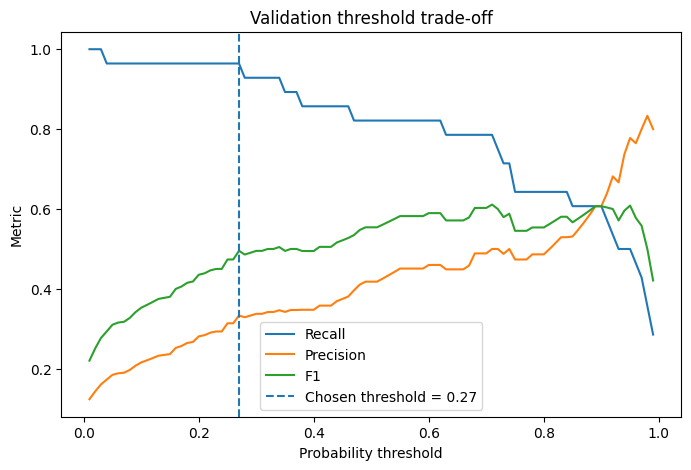

In [12]:
# Visualize the validation threshold trade-off for the selected candidate.
threshold_table = fitted_candidates[best_key]["threshold_table"]

plt.figure(figsize=(8, 5))
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Validation threshold trade-off")
plt.legend()
plt.show()


## 9. Refit on training + validation data and evaluate once on the test set

The model configuration and threshold are now frozen. The final test set is used exactly once for the primary performance estimate.


In [13]:
X_train_valid = pd.concat([X_train, X_valid], axis=0)
y_train_valid = pd.concat([y_train, y_valid], axis=0)

final_model = build_pipeline(clone(model_specs[best_model_name]["model"]))
final_model.set_params(**best_params)
final_model.fit(X_train_valid, y_train_valid)

test_scores = positive_scores(final_model, X_test)
test_pred = (test_scores >= best_threshold).astype(int)

test_metrics = pd.Series(
    metric_row(y_test, test_pred, test_scores),
    name="final_test",
)
display(test_metrics.to_frame())

print(classification_report(
    y_test,
    test_pred,
    target_names=["lower risk", "higher risk"],
    digits=3,
    zero_division=0,
))


,final_test
recall,1.000000
precision,0.307692
f1,0.470588
flag_rate,0.223039
pr_auc,0.778306
roc_auc,0.976128


              precision    recall  f1-score   support

  lower risk      1.000     0.834     0.910       380
 higher risk      0.308     1.000     0.471        28

    accuracy                          0.846       408
   macro avg      0.654     0.917     0.690       408
weighted avg      0.952     0.846     0.879       408



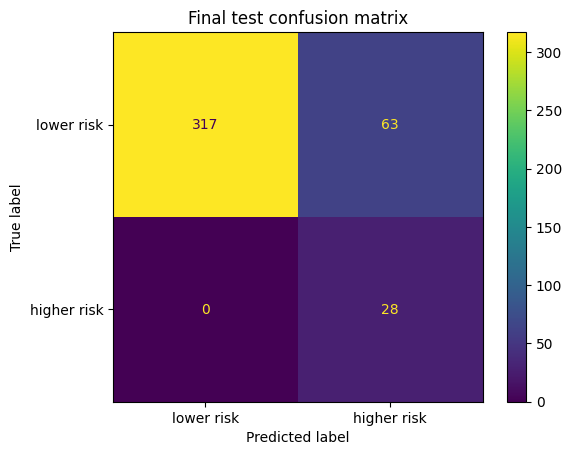

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["lower risk", "higher risk"],
    values_format="d",
)
plt.title("Final test confusion matrix")
plt.show()


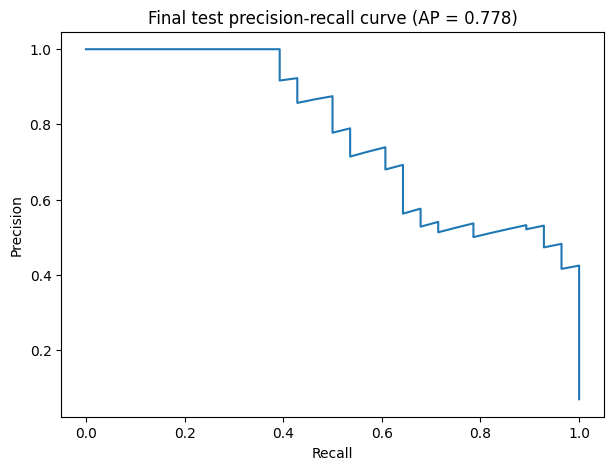

In [15]:
precision, recall, thresholds = precision_recall_curve(y_test, test_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Final test precision-recall curve (AP = {average_precision_score(y_test, test_scores):.3f})")
plt.show()


## 10. Error analysis

The following table keeps only row indices, true labels, predicted probabilities, and predictions. Avoid exporting raw sensitive survey variables unless there is a clear, authorized need.


In [16]:
error_analysis = pd.DataFrame({
    "row_index": X_test.index,
    "true_label": y_test.to_numpy(),
    "predicted_probability": test_scores,
    "predicted_label": test_pred,
})
error_analysis["error_type"] = np.select(
    [
        (error_analysis["true_label"] == 1) & (error_analysis["predicted_label"] == 0),
        (error_analysis["true_label"] == 0) & (error_analysis["predicted_label"] == 1),
    ],
    ["false_negative", "false_positive"],
    default="correct",
)

display(
    error_analysis[error_analysis["error_type"] != "correct"]
    .sort_values("predicted_probability")
    .head(30)
)

print(error_analysis["error_type"].value_counts())


,row_index,true_label,predicted_probability,predicted_label,error_type
250,201,0,0.270484,1,false_positive
99,505,0,0.274803,1,false_positive
92,1035,0,0.284162,1,false_positive
180,1221,0,0.284809,1,false_positive
332,2712,0,0.288413,1,false_positive
159,893,0,0.291121,1,false_positive
400,895,0,0.299273,1,false_positive
279,1692,0,0.313649,1,false_positive
202,1805,0,0.328496,1,false_positive
384,2067,0,0.331374,1,false_positive


error_type
correct           345
false_positive     63
Name: count, dtype: int64


## 11. Basic subgroup audit

Because category codes are anonymized, this is a performance consistency check rather than a substantive fairness conclusion. Groups with very small samples should not be interpreted.


In [17]:
def subgroup_metrics(feature_name, min_group_size=20):
    if feature_name not in X_test.columns:
        return pd.DataFrame()

    rows = []
    feature_values = X_test[feature_name]
    for group_value, group_indices in feature_values.groupby(feature_values, dropna=False).groups.items():
        positions = X_test.index.get_indexer(group_indices)
        yt = y_test.loc[group_indices]
        yp = test_pred[positions]
        ys = test_scores[positions]

        if len(group_indices) < min_group_size or yt.nunique() < 2:
            continue

        rows.append({
            "feature": feature_name,
            "group": group_value,
            "n": len(group_indices),
            "positive_n": int(yt.sum()),
            **metric_row(yt, yp, ys),
        })

    return pd.DataFrame(rows)

subgroup_tables = []
for feature in ["Demo_Gender", "Demo_Grade", "Demo_Major", "Demo_PreCollegeResidenceType"]:
    table = subgroup_metrics(feature)
    if not table.empty:
        subgroup_tables.append(table)

if subgroup_tables:
    subgroup_audit = pd.concat(subgroup_tables, ignore_index=True)
    display(subgroup_audit.sort_values(["feature", "recall"]))
else:
    print("No subgroup had enough test observations and both classes for a stable audit.")


,feature,group,n,positive_n,recall,precision,f1,flag_rate,pr_auc,roc_auc
0,Demo_Gender,1,136,10,1.0,0.285714,0.444444,0.257353,0.667746,0.965873
1,Demo_Gender,2,272,18,1.0,0.321429,0.486486,0.205882,0.827446,0.980096
2,Demo_Grade,1,211,8,1.0,0.200000,0.333333,0.189573,0.594912,0.965517
3,Demo_Grade,2,73,6,1.0,0.250000,0.400000,0.328767,0.948413,0.995025
4,Demo_Grade,3,59,6,1.0,0.600000,0.750000,0.169492,0.788492,0.974843
5,Demo_Grade,4,57,6,1.0,0.461538,0.631579,0.228070,0.910714,0.986928
6,Demo_Major,1,200,13,1.0,0.295455,0.456140,0.220000,0.784364,0.974907
7,Demo_Major,2,203,13,1.0,0.288889,0.448276,0.221675,0.788021,0.978138
8,Demo_PreCollegeResidenceType,1,170,11,1.0,0.297297,0.458333,0.217647,0.802712,0.975415
9,Demo_PreCollegeResidenceType,2,77,4,1.0,0.222222,0.363636,0.233766,0.798611,0.979452


## 12. Save the fitted model and reproducibility metadata

The exported artifact contains the full preprocessing pipeline, classifier, threshold, feature list, exclusions, and split seed. It should be used only for research or supervised screening—not diagnosis or autonomous intervention.


In [19]:
assert "Psy_Stress" not in feature_columns
assert not any(col.startswith("Psy_Stress") for col in feature_columns)

ARTIFACT_PATH = Path("depression_risk_pipeline.joblib")
METADATA_PATH = Path("depression_risk_metadata.json")

joblib.dump(final_model, ARTIFACT_PATH)

metadata = {
    "project": "Measuring Risk of Depression via Lifestyle Factors",
    "target_definition": "Psy_Depression >= 10",
    "target_column": TARGET,
    "source_target_column": TARGET_SOURCE,
    "selected_model": best_model_name,
    "selected_params": best_params,
    "probability_threshold": best_threshold,
    "random_state": RANDOM_STATE,
    "baseline": {
        "name": "stress_90th_percentile_rule",
        "source_column": "Psy_Stress",
        "training_percentile": 0.90,
        "training_cutoff": float(stress_cutoff),
        "used_as_model_feature": False,
    },
    "feature_columns": feature_columns,
    "excluded_columns": excluded_columns,
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "limitations": [
        "Target is a PHQ-derived screening proxy, not a clinical diagnosis.",
        "Category coding is incompletely documented.",
        "Single cross-sectional Chinese university cohort may not generalize.",
        "Model must not be used for punitive or autonomous decisions.",
    ],
}

METADATA_PATH.write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Saved:", ARTIFACT_PATH.resolve())
print("Saved:", METADATA_PATH.resolve())


Saved: /content/depression_risk_pipeline.joblib
Saved: /content/depression_risk_metadata.json


## 13. Example inference

A new case must use the same feature names as the training dataset. The pipeline handles imputation, encoding, and scaling.


In [20]:
def predict_risk(new_cases: pd.DataFrame) -> pd.DataFrame:
    missing = sorted(set(feature_columns) - set(new_cases.columns))
    if missing:
        raise ValueError(
            "New data is missing required columns. First missing columns: "
            + ", ".join(missing[:10])
        )

    scores = positive_scores(final_model, new_cases[feature_columns])
    labels = (scores >= best_threshold).astype(int)

    return pd.DataFrame({
        "higher_risk_probability": scores,
        "predicted_higher_risk": labels,
    }, index=new_cases.index)

# Demonstration only: score one held-out row without displaying its sensitive inputs.
example_prediction = predict_risk(X_test.iloc[[0]])
display(example_prediction)


,higher_risk_probability,predicted_higher_risk
690,0.190457,0
